# Project Sentinel — Exploratory Data Analysis

## tl;dr

Run the pipeline first; this notebook derives its findings from the generated silver and gold artifacts.

## Context & Methods

Validate class imbalance and the separability of enriched last-mile delivery risk signals.

### Key Assumptions

Synthetic telemetry is deterministic and illustrative; IEEE-CIS labels remain the supervised target.

## Data

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
df = pd.read_parquet(ROOT/'data/silver/spark_driver_trips.parquet')
print(df.shape, f'fraud rate={df.isFraud.mean():.3%}')

(12000, 52) fraud rate=3.383%


## Results

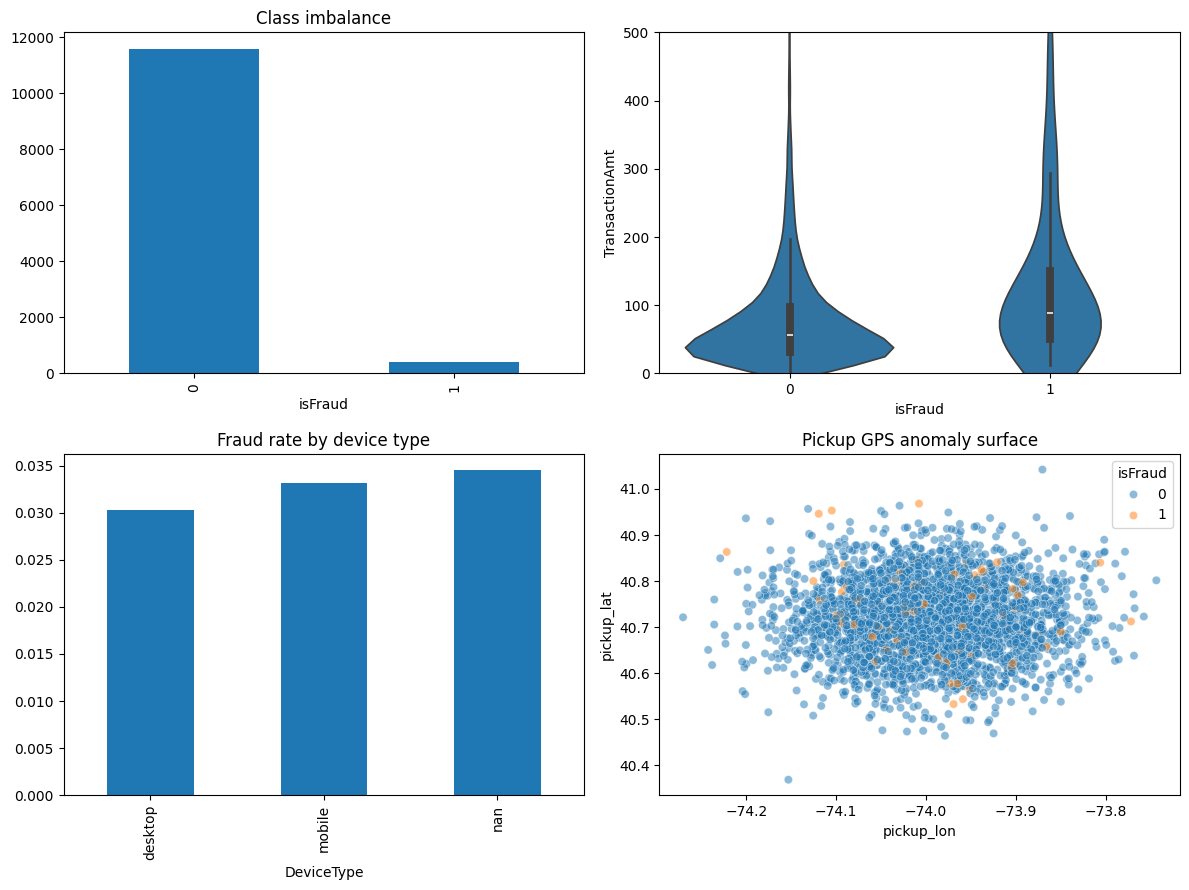

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
df.isFraud.value_counts().sort_index().plot.bar(ax=axes[0,0], title='Class imbalance')
sns.violinplot(data=df.sample(min(5000,len(df)), random_state=42), x='isFraud', y='TransactionAmt', ax=axes[0,1]); axes[0,1].set_ylim(0,500)
df.groupby('DeviceType', dropna=False).isFraud.mean().sort_values().plot.bar(ax=axes[1,0], title='Fraud rate by device type')
sns.scatterplot(data=df.sample(min(3000,len(df)), random_state=42), x='pickup_lon', y='pickup_lat', hue='isFraud', alpha=.5, ax=axes[1,1]); axes[1,1].set_title('Pickup GPS anomaly surface')
plt.tight_layout()

Text(0.5, 1.0, 'Risk-feature correlation')

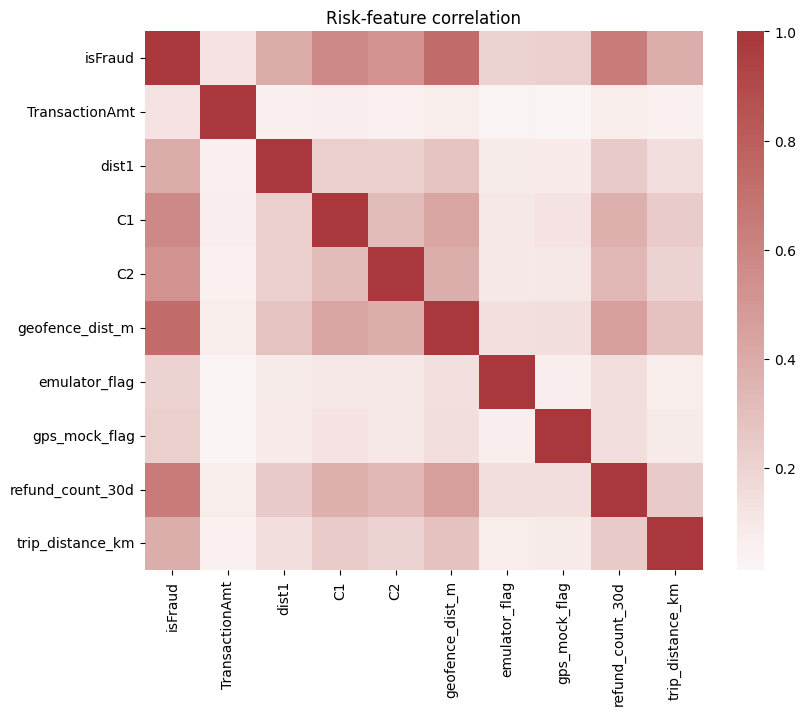

In [3]:
features=['isFraud','TransactionAmt','dist1','C1','C2','geofence_dist_m','emulator_flag','gps_mock_flag','refund_count_30d','trip_distance_km']
plt.figure(figsize=(9,7)); sns.heatmap(df[features].corr(numeric_only=True), cmap='vlag', center=0); plt.title('Risk-feature correlation')

## Takeaways

Use the executed charts and tables to explain how complementary detection layers reduce blind spots while preserving analyst review.